# Natural Language Processing: The Term-Document Matrix and Topic Modeling

In this course, we've already seen a few examples of working with text. We've used basic string operations and `pandas` `str` operations in order to manipulate text data. Now that we have some array programming and machine learning skills under our belt, we can take our exploration of text data much further. 


## The Term-Document Matrix
In this lecture, we'll introduce one of the most important constructs for analyzing text data: the [term-document matrix.](https://en.wikipedia.org/wiki/Document-term_matrix)

This might sound intimidating, but the idea is very simple. Consider the following three sentences. We regard each of them as a "document."

1. I like Star Trek. 
2. You like Star Trek. 
3. I like Totoro.

We can think of the term-document matrix as a data frame with a column for each possible word. In each column, we count up how many times that word appears in document. For example, using the three short "documents" above, the term-document matrix is: 

| document | I | you | like | star | trek | totoro |
|----------|---|-----|------|------|------|--------|
| 1        | 1 | 0   | 1    | 1    | 1    | 0      |
| 2        | 0 | 1   | 1    | 1    | 1    | 0      |
| 3        | 1 | 0   | 1    | 0    | 0    | 1      |

This turns out to be an extremely convenient format for working with text data, and we'll see in coming lectures how to use it for both sentiment analysis (figuring out how "positive" a word or sentence is) and topic modeling (figuring out the main "ideas" in a set of documents). 

If you're very persistent, you would be able to make a term-document matrix using a lot of `for`-loops and basic string operations. However, `scikit-learn` offers a much more convenient approach. In this lecture, we'll see an example of organizing our data and constructing the term-document matrix. In coming lectures, we'll start to use our construction for data analysis. 

## Data

Our data for this lecture is the complete text of the short book *Alice’s Adventures in Wonderland* by Lewis Carroll. The package `nltk` (Natural Language ToolKit) makes it wonderfully easy to obtain this data set. 

In [3]:
pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import nltk
nltk.download('gutenberg')

from nltk.corpus import gutenberg

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/muchasmesas/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


In [6]:
s = gutenberg.raw('Carroll-alice.txt')
print(type(s),len(s))

<class 'str'> 144395


In [7]:
s[:200]

"[Alice's Adventures in Wonderland by Lewis Carroll 1865]\n\nCHAPTER I. Down the Rabbit-Hole\n\nAlice was beginning to get very tired of sitting by her sister on the\nbank, and of having nothing to do: once"

We observe that the chapters are demaracted by the all-caps word "CHAPTER". So, we can simply split on this word to break the book up into chapters. We need to exclude the very first part of the split, since this isn't a real chapter -- it just contains the title and author information. 

In [8]:
chapters=s.split('CHAPTER')[1:]
len(chapters)

12

In [9]:
# number of characters in each chapter
print([len(c) for c in chapters])

[11452, 10989, 9552, 13871, 11986, 13860, 12688, 13656, 12618, 11528, 10392, 11661]


There's lots of punctuation and special characters in the text, but we don't have to worry about those this time -- there are built-in functions that will filter these out for us. 

It's helpful to keep ourselves organized by placing the text of each chapter into a data frame. 

In [12]:
df0 = pd.DataFrame({'Chapter': range(1, len(chapters) + 1), 'text': chapters})
df = df0.copy()
df

,Chapter,text
0,1,I. Down the Rabbit-Hole\n\nAlice was beginnin...
1,2,II. The Pool of Tears\n\n'Curiouser and curio...
2,3,III. A Caucus-Race and a Long Tale\n\nThey we...
3,4,IV. The Rabbit Sends in a Little Bill\n\nIt w...
4,5,V. Advice from a Caterpillar\n\nThe Caterpill...
5,6,VI. Pig and Pepper\n\nFor a minute or two she...
6,7,VII. A Mad Tea-Party\n\nThere was a table set...
7,8,VIII. The Queen's Croquet-Ground\n\nA large r...
8,9,IX. The Mock Turtle's Story\n\n'You can't thi...
9,10,X. The Lobster Quadrille\n\nThe Mock Turtle s...


Next, we are going to grab the `CountVectorizer` function from the `sklearn.feature_extraction.text` module. This module gives a whole range of tools for turning unstructured text into quantitative numbers that we can feed into algorithms. 

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
vec= CountVectorizer(stop_words='english')
counts = vec.fit_transform(df['text'])      # transforming on the 'text'' col
print(type(counts))

<class 'scipy.sparse._csr.csr_matrix'>


The CountVectorizer returns a sparse matrix. Sparse matrices are useful, but for this course wee can convert it into a regular two-dimensional numpy array

In [14]:
counts.toarray()

array([[0, 0, 0, ..., 0, 1, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(12, 2312))

The matrix can be converted into a DataFrame with labeled columns using vec.get_feature_names_out()

In [17]:
count_df = pd.DataFrame(counts.toarray(), columns=vec.get_feature_names_out())
count_df

,_i_,abide,able,absence,absurd,acceptance,accident,accidentally,account,accounting,...,years,yelled,yelp,yer,yes,yesterday,young,youth,zealand,zigzag
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,4,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,6,0,1
5,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,1,0,0,0
7,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,2,1,0,0,0,0
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,3,0,2,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,2,1,0,0,0,0


In [18]:
df = pd.concat((df,count_df),axis=1)
df

,Chapter,text,_i_,abide,able,absence,absurd,acceptance,accident,accidentally,...,years,yelled,yelp,yer,yes,yesterday,young,youth,zealand,zigzag
0,1,I. Down the Rabbit-Hole\n\nAlice was beginnin...,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,2,II. The Pool of Tears\n\n'Curiouser and curio...,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3,III. A Caucus-Race and a Long Tale\n\nThey we...,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,1,0,0,0
3,4,IV. The Rabbit Sends in a Little Bill\n\nIt w...,0,0,0,0,0,0,0,0,...,0,0,1,4,0,0,0,0,0,0
4,5,V. Advice from a Caterpillar\n\nThe Caterpill...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,6,0,1
5,6,VI. Pig and Pepper\n\nFor a minute or two she...,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,VII. A Mad Tea-Party\n\nThere was a table set...,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,1,0,0,0
7,8,VIII. The Queen's Croquet-Ground\n\nA large r...,0,0,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
8,9,IX. The Mock Turtle's Story\n\n'You can't thi...,0,0,0,1,0,0,0,0,...,0,0,0,0,3,0,2,0,0,0
9,10,X. The Lobster Quadrille\n\nThe Mock Turtle s...,0,0,0,0,0,0,0,0,...,0,1,0,0,2,1,0,0,0,0


## Interpreting the Term-Document Matrix

We can now use the Term-Document matrix to check how frequently a given term appears in each chapter of the novel. For example: 

In [20]:
df['alice']

# using the Term Doc Matrix to see how many times a name appears in each chapter!

0     28
1     26
2     23
3     31
4     35
5     43
6     51
7     39
8     52
9     30
10    16
11    23
Name: alice, dtype: int64

We can also plot terms to see how often they appear over time: 

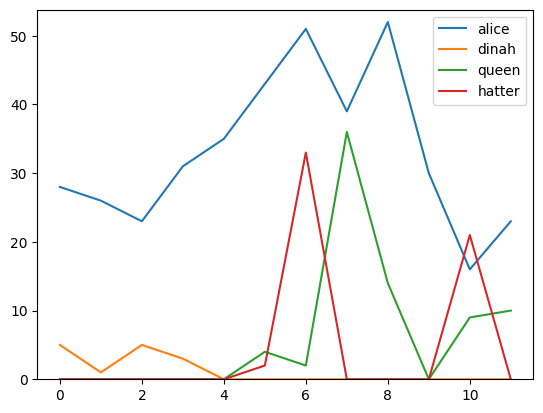

In [21]:
fig, ax = plt.subplots(1,1)
for term in ['alice','dinah','queen','hatter']:
    ax.plot(df[term],label=term)
    ax.set(ylim=(0,None))
    ax.legend()

We can see that Alice is a prominent character throughout the entirety of the book. In contrast, Dinah (Alice's pet cat) only appears in the first half of the book, and the Mad Hatter appears in just a few specific chapters. 

## Topic Modeling

For topic modeling, we use CountVectorizer again. This time, max_df is set to 0.5 so that words
appearing in more than 50 percent of chapters are excluded.

In [23]:
vec = CountVectorizer(max_df = 0.5,stop_words='english')
df = df0.copy()

counts = vec.fit_transform(df['text'])      #transforming the text col ofc
counts = counts.toarray()                   # turn it into a numpy array
counts_df = pd.DataFrame(counts, columns=vec.get_feature_names_out())   # turn to df
df = pd.concat((df,count_df),axis=1)                                    # combine them
df

,Chapter,text,_i_,abide,able,absence,absurd,acceptance,accident,accidentally,...,years,yelled,yelp,yer,yes,yesterday,young,youth,zealand,zigzag
0,1,I. Down the Rabbit-Hole\n\nAlice was beginnin...,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,2,II. The Pool of Tears\n\n'Curiouser and curio...,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3,III. A Caucus-Race and a Long Tale\n\nThey we...,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,1,0,0,0
3,4,IV. The Rabbit Sends in a Little Bill\n\nIt w...,0,0,0,0,0,0,0,0,...,0,0,1,4,0,0,0,0,0,0
4,5,V. Advice from a Caterpillar\n\nThe Caterpill...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,6,0,1
5,6,VI. Pig and Pepper\n\nFor a minute or two she...,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,VII. A Mad Tea-Party\n\nThere was a table set...,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,1,0,0,0
7,8,VIII. The Queen's Croquet-Ground\n\nA large r...,0,0,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
8,9,IX. The Mock Turtle's Story\n\n'You can't thi...,0,0,0,1,0,0,0,0,...,0,0,0,0,3,0,2,0,0,0
9,10,X. The Lobster Quadrille\n\nThe Mock Turtle s...,0,0,0,0,0,0,0,0,...,0,1,0,0,2,1,0,0,0,0


Topic modeling is an unsupervised machine learning framework, which means that there are no
true labels y. We only create the variables X by dropping the text and Chapter columns.

In [24]:
X = df.drop(['text','Chapter'], axis=1)     # this is familiar, dropping columns for X
X

,_i_,abide,able,absence,absurd,acceptance,accident,accidentally,account,accounting,...,years,yelled,yelp,yer,yes,yesterday,young,youth,zealand,zigzag
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,4,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,6,0,1
5,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,1,0,0,0
7,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,2,1,0,0,0,0
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,3,0,2,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,2,1,0,0,0,0


here are many algorithms for topic modeling. Here we use nonnegative matrix factorization,
abbreviated NMF. The three steps are to import the model, initialize an instance, and fit it on data.

-   1. Import the model we want.
-   2. Initialize an instance of the model.
-   3. Fit the model on data.

NMF requires n_components, the number of topics to find. Choosing the number of topics is
partly an art, though there are also quantitative approaches.

In [25]:
from sklearn.decomposition import NMF   # importing the model we want

model = NMF(n_components=4, init='random',random_state=0)       # initialize instance of model

model.fit(X)                # fit model on data

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",4
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",'random'
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",0
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


The topics themselves are stored in the components_ attribute of the model.

In [27]:
print(model.components_)
print(model.components_.shape)

[[0.00000000e+00 5.93781010e-02 0.00000000e+00 ... 6.14493563e-01
  0.00000000e+00 1.02415594e-01]
 [0.00000000e+00 5.35464509e-05 0.00000000e+00 ... 1.32652329e-01
  0.00000000e+00 2.21087214e-02]
 [1.02309724e-01 7.67856597e-02 1.26737004e-01 ... 1.40537589e-01
  1.16404743e-01 2.34229315e-02]
 [1.66986227e-01 6.02533737e-02 0.00000000e+00 ... 3.93331236e-01
  0.00000000e+00 6.55552059e-02]]
(4, 2312)


Each component can be interpreted as a collection of weights for each word. The most important
words in a component are the words with the largest weights.

In [28]:
orders = np.argsort(model.components_, axis=1)
important_words = np.array(X.columns)[orders]
important_words

array([['_i_', 'hurried', 'hung', ..., 'hatter', 'alice', 'said'],
       ['_i_', 'hungry', 'hung', ..., 'turtle', 'alice', 'said'],
       ['lived', 'dreaming', 'proud', ..., 'said', 'little', 'alice'],
       ['lived', 'flavour', 'flowers', ..., 'queen', 'alice', 'said']],
      shape=(4, 2312), dtype=object)

In [30]:
def top_words(X, model, component, num_words):
    orders = np.argsort(model.components_, axis=1)
    important_words = np.array(X.columns)[orders]
    return important_words[component][-num_words:]

top_words(X, model, 3, 5)

array(['head', 'king', 'queen', 'alice', 'said'], dtype=object)

The assignment of topics per document is represented by weights. We access these using the
transform method.

In [32]:
weights = model.transform(X)
print(weights)
print(weights.shape)

[[0.         0.         1.8194661  0.        ]
 [0.         0.         1.98096544 0.        ]
 [0.18744673 0.17436902 0.7419094  0.29720907]
 [0.         0.         2.29672454 0.        ]
 [0.29336044 0.29721771 0.61445213 0.61913216]
 [0.22883629 0.19592931 1.37849254 0.63897512]
 [1.34391014 0.         0.02239581 0.        ]
 [0.         0.         0.34302757 1.75543017]
 [0.05947709 1.66829478 0.41494646 0.48607243]
 [0.         1.96485161 0.         0.        ]
 [0.34806466 0.         0.         0.87358409]
 [0.08635765 0.12899298 0.         1.38055626]]
(12, 4)


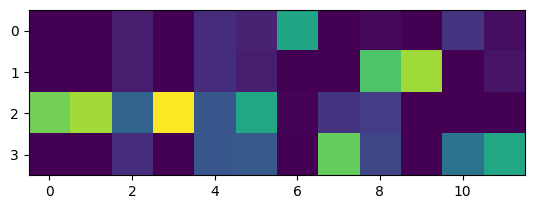

In [33]:
fig, ax = plt.subplots(1,1)
im = ax.imshow(weights.T)

The weights indicate the relative presence of each topic in each chapter. For example, Topic 2 is
highly present in the first six chapters, but then mostly absent for the rest of the book. Topic 3
appears in Chapters 8, 11, and 12.

/var/folders/r6/n0wh2lcs2dl98_73bdgpck3h0000gn/T/ipykernel_89828/3959432680.py:3: MatplotlibDeprecationWarning: Passing label as a length 5 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(df['Chapter'],weights[:,i], label=top_words(X,model,i,5))


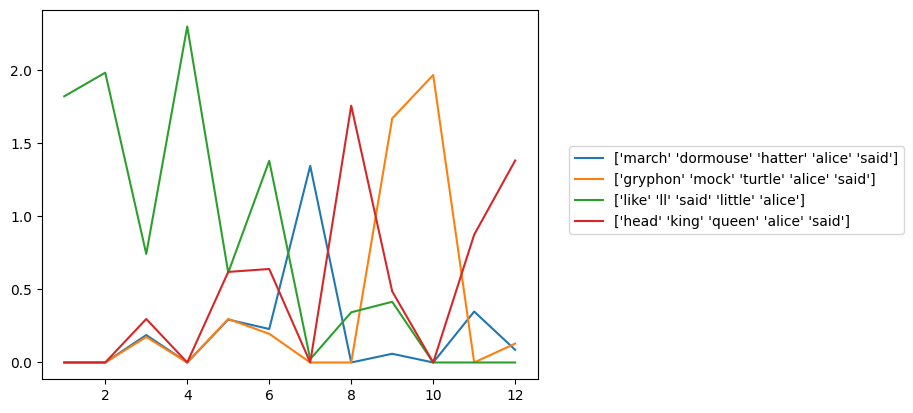

In [35]:
fig, ax = plt.subplots(1,1)
for i in range(4):
    ax.plot(df['Chapter'],weights[:,i], label=top_words(X,model,i,5))
ax.legend(bbox_to_anchor=(1.05,0.65),loc='upper left')

This plot allows us to see several major features of the novel, including the tea party with the
March Hare, the Mad Hatter, and the Dormouse in Chapter 7; the croquet game in the court of
the Queen of Hearts in Chapter 8; the appearance of the Mock Turtle and the Lobster in Chapters
9 and 10; and the reappearance of many characters in Chapter 11.